# Variable Time Shift 

This notebook contains an example of performing a variable time shift.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import WDM
from WDM.code.discrete_wavelet_transform import WDM 
import time 

Let's start by creating an example signal. We will use a sine-Gaussian.

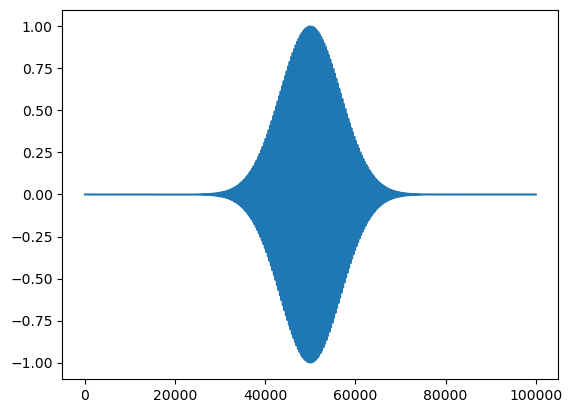

In [2]:
fs = 0.2    # sampling frequency [Hz]
T = 1.0e5   # duration [s]
f0 = 3.0e-3 # central frequency [Hz]
w = T/15.   # duration [s]

f = lambda t: np.exp(-0.5*((t-T/2.)/w)**2)*np.sin(2*np.pi*f0*t)

times = np.arange(0, T, 1/fs)
signal = f(times)

fig, ax = plt.subplots()
ax.plot(times, signal)
plt.show()

In [3]:
N = times.shape[0]
Nf = 200

wdm = WDM.WDM_transform(dt=1/fs, Nf=Nf, N=N, q=32, calc_m0=True)

In [4]:
print(wdm)

WDM_transform(Nf=200, N=20000, q=32, d=4, A_frac=0.25, calc_m0=True)
self.Nt = 100 time cells
self.Nf = 200 frequency cells
self.dT = 1000.0 time resolution
self.dF = 0.0005 frequency resolution
self.dt = 5.0 time series cadence
self.df = 1e-05 time series fft frequency resolution
self.K = 12800 window length


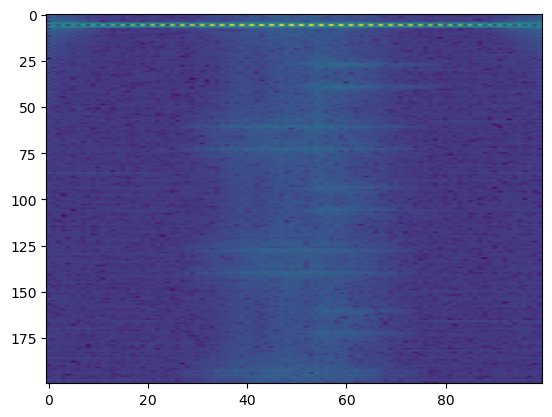

In [5]:
fig, ax = plt.subplots()
ax.imshow(np.log(np.abs(wdm(signal).T)), aspect='auto')
plt.show()

In [6]:
delta_constant = (T/10.) * np.ones(wdm.N)

print(delta_constant)

[10000. 10000. 10000. ... 10000. 10000. 10000.]


In [7]:
delta_variable = (T/10.) * np.ones(wdm.N) + (T/1000.)*times/T

print(delta_variable)

[10000.    10000.005 10000.01  ... 10099.985 10099.99  10099.995]


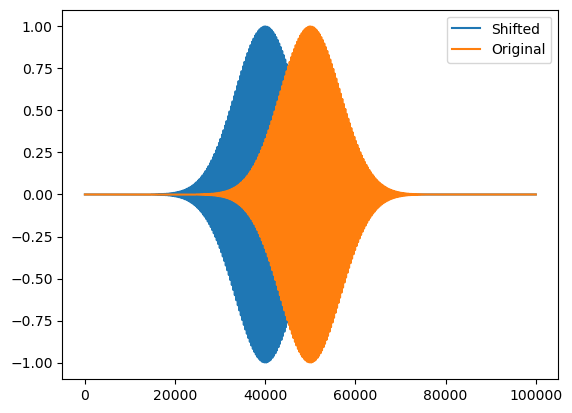

In [8]:
#Constant time-shift: 

#1) Time Domain Version 

t_shifted = times + delta_constant

signal_constant_td = np.interp(t_shifted,times,signal)

plt.plot(times, signal_constant_td, label='Shifted')
plt.plot(times, signal, label='Original')
plt.legend()
plt.show()




In [9]:
wdm.build_time_delay_filter_interpolants(30,30)

In [10]:
#2) Time-Freq Domain Version 

wdm_times = np.arange(0,wdm.dT*wdm.Nt,wdm.dT)
wdm_signal = wdm(signal)

delta_constant_wdm = np.interp(wdm_times,times,delta_constant)




wdm_shifted = wdm.apply_variable_time_shift(wdm_signal, delta_constant_wdm)




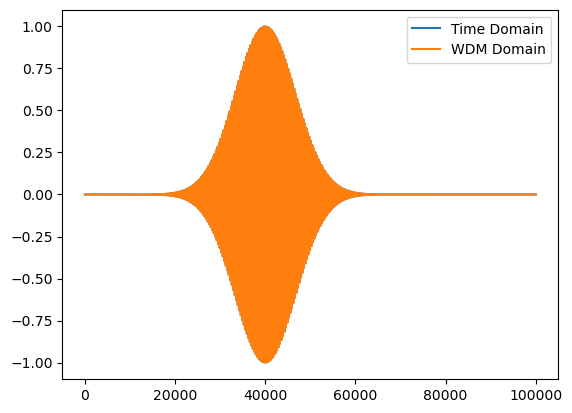

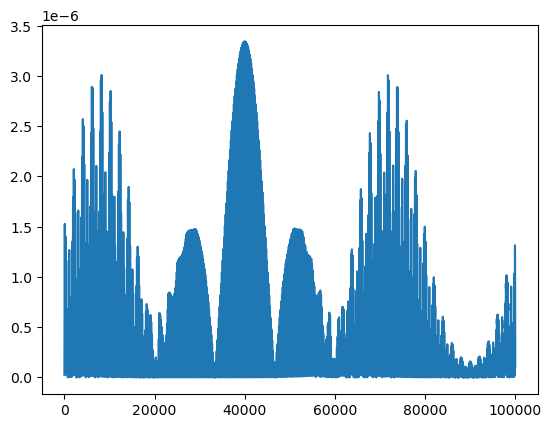

In [11]:
td_signal_constant_from_wdm = wdm.idwt(wdm_shifted)

plt.plot(times, signal_constant_td, label='Time Domain')
plt.plot(times, td_signal_constant_from_wdm, label='WDM Domain')
plt.legend()
plt.show()

plt.plot(times, np.abs(signal_constant_td-td_signal_constant_from_wdm))
plt.show()

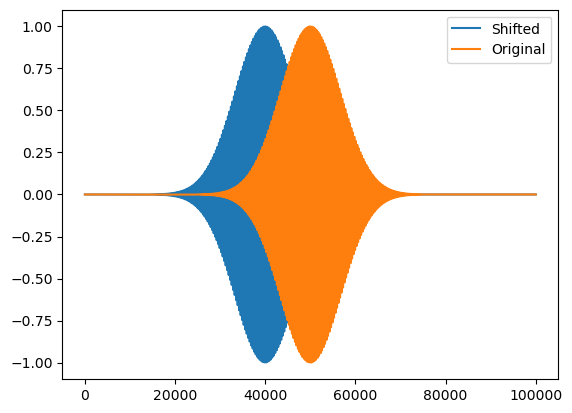

In [12]:
#Varable time-shift: 

#1) Time Domain Version 

t_shifted_var = times + delta_variable

signal_variable_td = np.interp(t_shifted_var,times,signal)

plt.plot(times, signal_variable_td, label='Shifted')
plt.plot(times, signal, label='Original')
plt.legend()
plt.show()

In [13]:
#2) Time-Freq Domain Version 


delta_variable_wdm = np.interp(wdm_times,times,delta_variable)

t0 = time.time()
wdm_shifted_var = wdm.apply_variable_time_shift(wdm_signal, delta_variable_wdm)
t1 = time.time()

print("Elapsed Application Time:", t1-t0)

Elapsed Application Time: 0.0035429000854492188


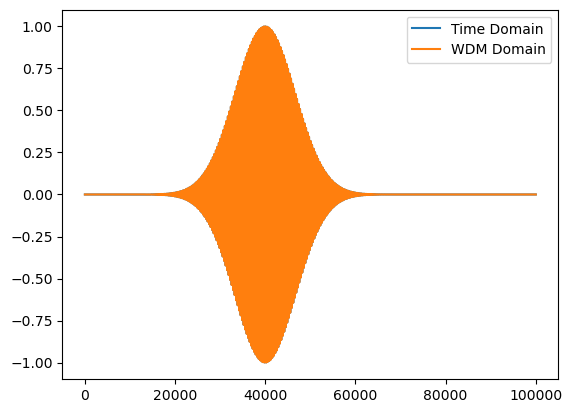

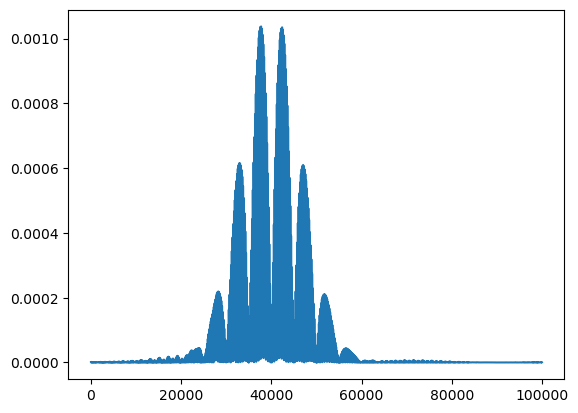

In [14]:
td_signal_variable_from_wdm = wdm.idwt(wdm_shifted_var)

plt.plot(times, signal_variable_td, label='Time Domain')
plt.plot(times, td_signal_variable_from_wdm, label='WDM Domain')
plt.legend()
plt.show()

plt.plot(times, np.abs(signal_variable_td-td_signal_variable_from_wdm))
plt.show()